# X Bot Detection: Analysis Notebook
Author: Mohamed Bucheeri
Date: April 17 2026

This notebook goes with the `twitter-bot-detector` project. The README has the problem framing, dataset, how to run the code, and the results summary.

## Contents
1. Exploratory Data Analysis
2. Feature Engineering and Analysis
3. Model Comparison
4. Live Demo on Sample Profiles
5. Per-Prediction Explainability
6. Ablation: Sentence-BERT Bio Embeddings
7. Post-Deployment Benchmark on 50 Verified Organisations
8. External Validation on MGTAB
9. Limitations and Ethical Considerations
10. Conclusion

In [33]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
import sys; sys.path.insert(0, '..')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from src.data import load_and_preprocess
from src.config import numeric_features, checkpoints
from api.app import predict, load_model

load_model()

plt.style.use('dark_background')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.titleweight': 'bold', 'axes.labelsize': 11, 'legend.fontsize': 10, 'figure.titleweight': 'bold'})
human_color = 'green'
bot_color = 'red'
model_colors = {'bigru_lstm': 'tab:blue', 'cnn_bilstm': 'tab:orange', 'xgboost': 'tab:green'}

## 1. Exploratory Data Analysis
Before training, we want to know how big the dataset is, how the classes are balanced, and which features actually look different between humans and bots. The answers will justify the training choices in later sections.

### 1.1 Dataset Overview
Start with the dataset's scale and label distribution.

In [34]:
users_df, texts, labels, splits, user_ids = load_and_preprocess()
users_df['text_length'] = [len(t) for t in texts]

n_total = len(users_df)
n_humans = int((users_df['label'] == 0).sum())
n_bots = int((users_df['label'] == 1).sum())
summary = pd.DataFrame({
    'Metric': ['Total users', 'Human accounts', 'Bot accounts',
               'Class ratio (human:bot)', 'Numeric features',
               'Train / Val / Test split'],
    'Value': [f'{n_total:,}',
              f'{n_humans:,} ({n_humans/n_total:.1%})',
              f'{n_bots:,} ({n_bots/n_total:.1%})',
              f'{n_humans/n_bots:.2f} : 1',
              f'{len(numeric_features)}',
              f'{len(splits["train"]):,} / {len(splits["val"]):,} / {len(splits["test"]):,}'],
})
print('Table 1: Dataset Summary Statistics')
print('=' * 55)
summary

Loading dataset
Rows: 37,438
Bots: 12,425, humans: 25,013
Engineered 37 features
Split: 26,206 train, 5,616 val, 5,616 test
Preprocessed 37,438 users
Table 1: Dataset Summary Statistics


,Metric,Value
0,Total users,"37,438"
1,Human accounts,"25,013 (66.8%)"
2,Bot accounts,"12,425 (33.2%)"
3,Class ratio (human:bot),2.01 : 1
4,Numeric features,37
5,Train / Val / Test split,"26,206 / 5,616 / 5,616"


The dataset contains 37,438 labelled accounts. This is enough to train on, but small compared to academic benchmarks like TwiBot-22 (around 1 million users). The class split is around 2 humans for every bot. A model that always predicts human would already be 66.8% accurate, so accuracy on its own is misleading, and F1 and ROC-AUC are better primary metrics. The imbalance also means the training loss needs to weight bot examples more heavily, otherwise the model learns to ignore the minority class. Both choices will be clearer in the training pipeline.

### 1.2 Class Distribution
The same counts as a bar chart and a pie chart.

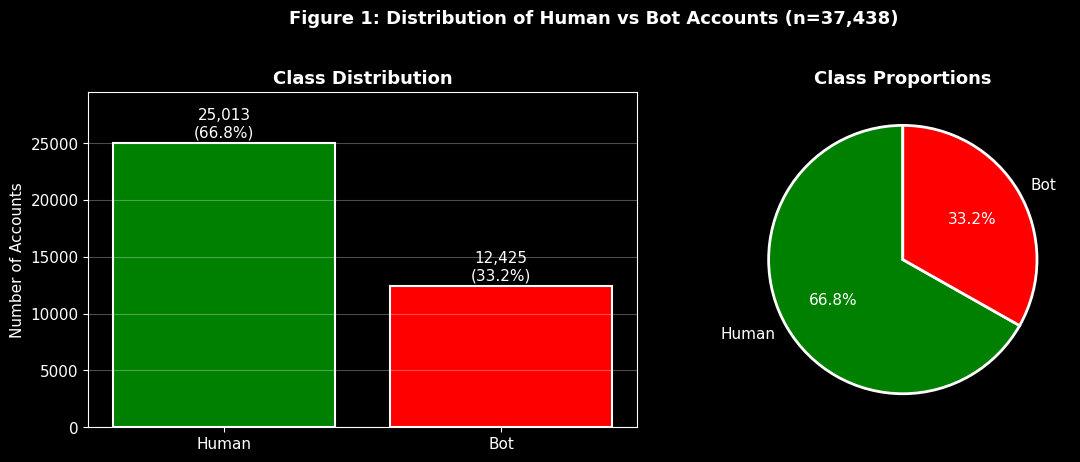

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

counts = users_df['label'].value_counts().sort_index()
bars = ax1.bar(['Human', 'Bot'], counts.values,
               color=[human_color, bot_color], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 300,
             f'{val:,}\n({val/n_total:.1%})', ha='center', va='bottom', fontsize=11)
ax1.set_ylabel('Number of Accounts')
ax1.set_title('Class Distribution')
ax1.set_ylim(0, max(counts.values) * 1.18)
ax1.grid(axis='y', alpha=0.3)

ax2.pie(counts.values, labels=['Human', 'Bot'],
        colors=[human_color, bot_color],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Class Proportions')

plt.suptitle('Figure 1: Distribution of Human vs Bot Accounts (n=37,438)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Humans (25,013) outnumber bots (12,425) by around 2:1. The imbalance is moderate, not severe, so I did not need SMOTE or focal loss. Weighting the loss by class was enough. The training script uses a positive class weight of 2.03 for the neural networks and `scale_pos_weight = 2.03` for XGBoost.

### 1.3 Feature Distributions
Class balance tells us how many of each. Feature distributions tell us whether the features actually separate the classes. Below are the six features that a Random Forest baseline ranked as most discriminative, with humans in green and bots in red.

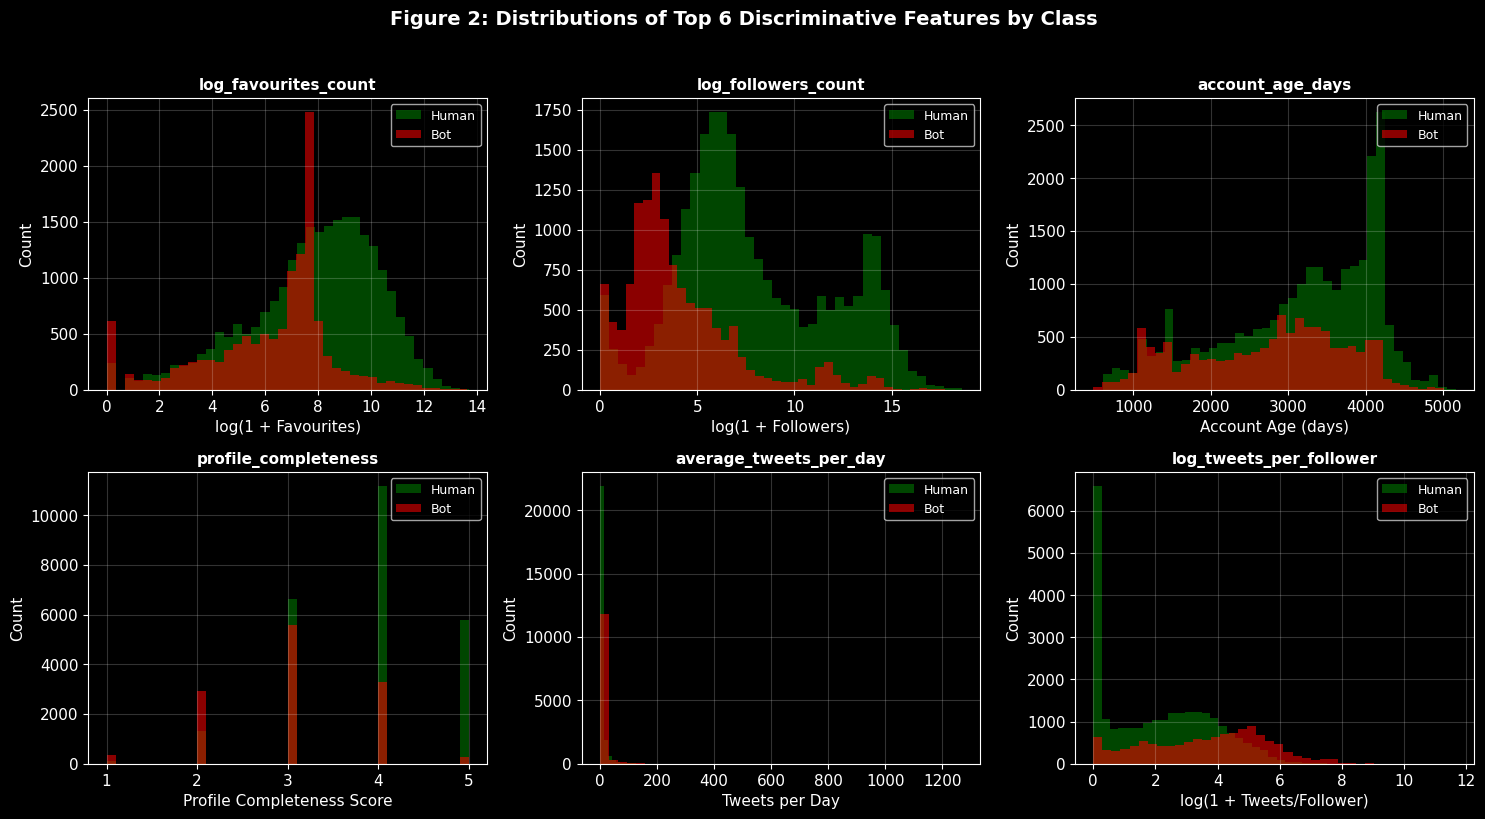

In [36]:
top_features = [
    ('log_favourites_count', 'log(1 + Favourites)'),
    ('log_followers_count', 'log(1 + Followers)'),
    ('account_age_days', 'Account Age (days)'),
    ('profile_completeness', 'Profile Completeness Score'),
    ('average_tweets_per_day', 'Tweets per Day'),
    ('log_tweets_per_follower', 'log(1 + Tweets/Follower)'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (feat, label) in zip(axes.ravel(), top_features):
    for cls, color, name in [(0, human_color, 'Human'), (1, bot_color, 'Bot')]:
        data = users_df[users_df['label'] == cls][feat]
        ax.hist(data, bins=40, alpha=0.55,
                color=color, label=name, edgecolor='none')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(feat, fontsize=11)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.2)

plt.suptitle('Figure 2: Distributions of Top 6 Discriminative Features by Class',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Each panel overlays the bot and human distributions. In `log_favourites_count` (top left), bots cluster near zero while humans spread between 4 and 12. `log_followers_count` looks similar. Bots sit below 5 and humans extend past 15. `account_age_days` shows bots overrepresented in accounts under 1,500 days. `profile_completeness` is a 0 to 5 score where bots cluster at 1 to 2 and humans at 3 to 5. `average_tweets_per_day` has a long right tail that is almost all bots posting more than 100 tweets a day. `log_tweets_per_follower` shows bots posting more relative to their audience size than humans do.

Every panel has overlap between the two classes, so no single feature separates them cleanly. The classifier will have to combine signal from many features.

### 1.4 Profile Description Length
How long are bios for the two classes?

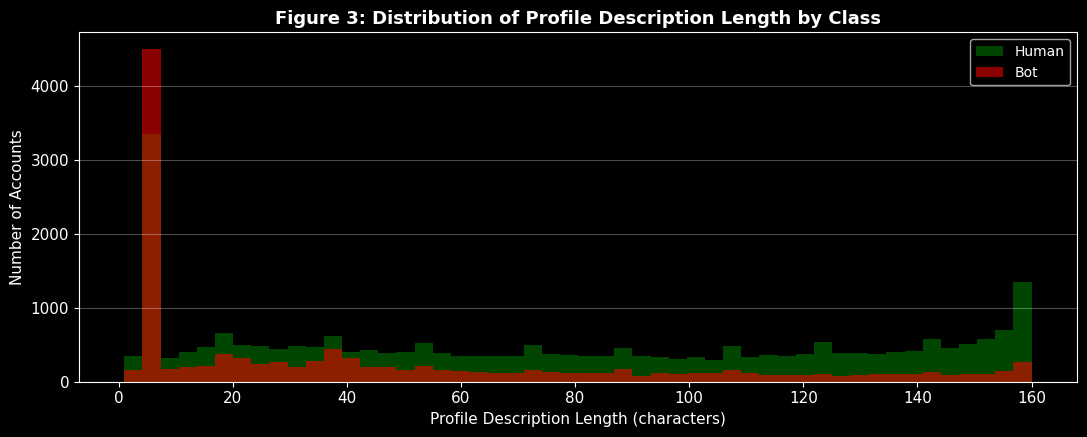

In [37]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for cls, color, name in [(0, human_color, 'Human'), (1, bot_color, 'Bot')]:
    data = users_df[users_df['label'] == cls]['text_length']
    ax.hist(data, bins=50, alpha=0.55, color=color, label=name, edgecolor='none')
ax.set_xlabel('Profile Description Length (characters)')
ax.set_ylabel('Number of Accounts')
ax.set_title('Figure 3: Distribution of Profile Description Length by Class')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The tall red spike near zero characters is the most obvious difference in the EDA. A lot of bot accounts have empty or near-empty bios. The preprocessing replaces empty strings with an `<EMPTY>` placeholder, which itself is short. Humans spread more evenly across the longer bios. There are still humans with short bios and bots with long ones, but the gap at zero is big enough that bio length on its own helps the classifier. The `description_length` and `has_description` features capture this.

## 2. Feature Engineering and Analysis
The EDA showed differences between humans and bots that the raw fields already capture. This section turns those raw fields into 37 engineered features and checks which of them matter most for classification.

### 2.1 Engineered Feature Categories
I engineered 37 numeric features across 8 categories. Each category covers a different kind of signal.

In [38]:
feature_table = pd.DataFrame([
    ('Raw Counts',
     'followers_count, friends_count, statuses_count, favourites_count, account_age_days, average_tweets_per_day',
     6),
    ('Log Transforms',
     'log versions of skewed counts (handles 0 to 100M+ range)',
     6),
    ('Behavioural Ratios',
     'followers_to_friends, favourites_to_statuses, statuses_to_followers, friends_to_followers',
     4),
    ('Profile Completeness',
     'verified, default_profile, default_profile_image, has_description, has_location, profile_completeness, description_length, screen_name_length',
     8),
    ('Screen Name Patterns',
     'digit count, digit ratio, has underscore',
     3),
    ('Activity Anomalies',
     'tweets per follower, tweets/day per follower',
     2),
    ('Bio Content Signals',
     'URL count, hashtag count, mention count, word count',
     4),
    ('Account-type Signals',
     'has_news_keywords, has_org_keywords, likely_organisation, is_established_account',
     4),
], columns=['Category', 'Examples', 'Count'])

print('Table 2: Engineered Feature Categories (37 total)')
print('=' * 60)
feature_table

Table 2: Engineered Feature Categories (37 total)


,Category,Examples,Count
0,Raw Counts,"followers_count, friends_count, statuses_count...",6
1,Log Transforms,log versions of skewed counts (handles 0 to 10...,6
2,Behavioural Ratios,"followers_to_friends, favourites_to_statuses, ...",4
3,Profile Completeness,"verified, default_profile, default_profile_ima...",8
4,Screen Name Patterns,"digit count, digit ratio, has underscore",3
5,Activity Anomalies,"tweets per follower, tweets/day per follower",2
6,Bio Content Signals,"URL count, hashtag count, mention count, word ...",4
7,Account-type Signals,"has_news_keywords, has_org_keywords, likely_or...",4


Raw counts like followers and statuses have a very wide value range. A human can have 50 followers or 50 million, so the raw number is a poor feature on its own. The other seven categories transform or add to these raw fields.

Log transforms pull the wide count ranges into a narrower scale so the model can use them directly. Behavioural ratios combine two counts into one number. The ratio of favourites to statuses, for example, catches bots that tweet a lot but receive almost no likes. Profile completeness measures how much of the profile the account filled in. Many bots skip this step. Screen name patterns flag usernames with a lot of digits, since automated signups tend to produce names like `user_38472`.

Activity anomalies flag accounts whose posting rate is too high for their follower count. Bio content signals count the URLs, hashtags, and mentions inside the bio, which are common in spam accounts. Account-type signals are four flags for news and brand bios. The airt-ml dataset does not label organisation accounts separately from individual humans, so without these flags the model has no direct way to tell a high-volume verified organisation apart from a bot. Section 7 tests how well this works on a custom benchmark of 50 real organisation accounts.

### 2.2 Feature Importance
A Random Forest classifier ranks features by how much they reduce uncertainty in the prediction. I fit it on the training split only to avoid leakage, then plot the top 15.

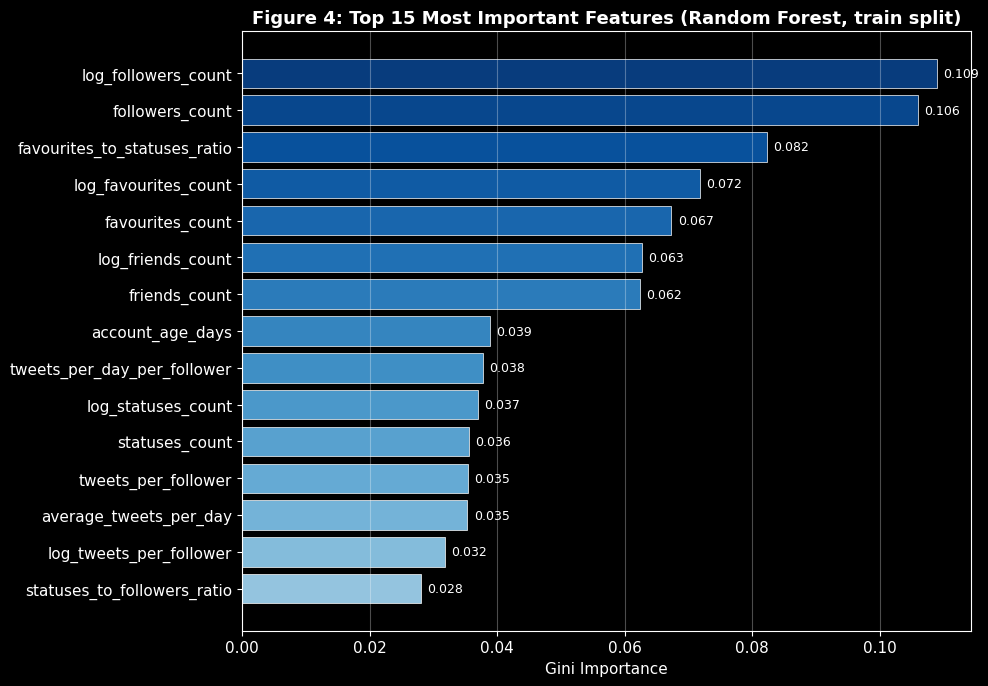

In [39]:
train_idx = [int(uid) for uid in splits['train']]
X_train = users_df.iloc[train_idx][numeric_features].fillna(0)
y_train = labels[train_idx]
rf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=1)
rf.fit(X_train, y_train)
importance = pd.Series(rf.feature_importances_, index=numeric_features)
top15 = importance.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_grad = plt.cm.Blues(np.linspace(0.4, 0.95, len(top15)))
ax.barh(range(len(top15)), top15.values, color=colors_grad, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15.index)
ax.set_xlabel('Gini Importance')
ax.set_title('Figure 4: Top 15 Most Important Features (Random Forest, train split)')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(top15.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
top_feats = importance.sort_values(ascending=False).head(12).index.tolist()

Three things we can observe from the ranking:
1. The log-transformed counts (`log_followers_count`, `log_favourites_count`, `log_friends_count`, `log_statuses_count`) dominate the top half of the ranking, and `log_followers_count` is the most important feature at 0.108. Log transforms outrank their raw counterparts for `followers_count`, `favourites_count`, and `statuses_count`. For `friends_count` the raw value is slightly above `log_friends_count`, so the log advantage is real but not universal.

2. `favourites_to_statuses_ratio` is the third most important feature overall at 0.082, ahead of every raw count except `followers_count`. It flags bots that post a lot but get few likes.

3. No single feature has Gini importance above 0.11. Of the top 10 features, 4 are log transforms, 1 is a behavioural ratio, 4 are raw counts, and 1 is an activity-anomaly feature (`tweets_per_day_per_follower`). The model relies on many moderate signals rather than one or two strong ones.

Note: The Random Forest ranking here is a diagnostic baseline. The deployed XGBoost weights the account-type flags (particularly `is_established_account`) much higher, which is visible in section 3 and in the per-prediction contributions in section 5.

### 2.3 Feature Correlation Matrix
Importance tells us which features matter on their own. Correlation tells us whether features carry overlapping information. I restrict the matrix to the top 12 features, since a full 37 by 37 grid would be too dense to read.

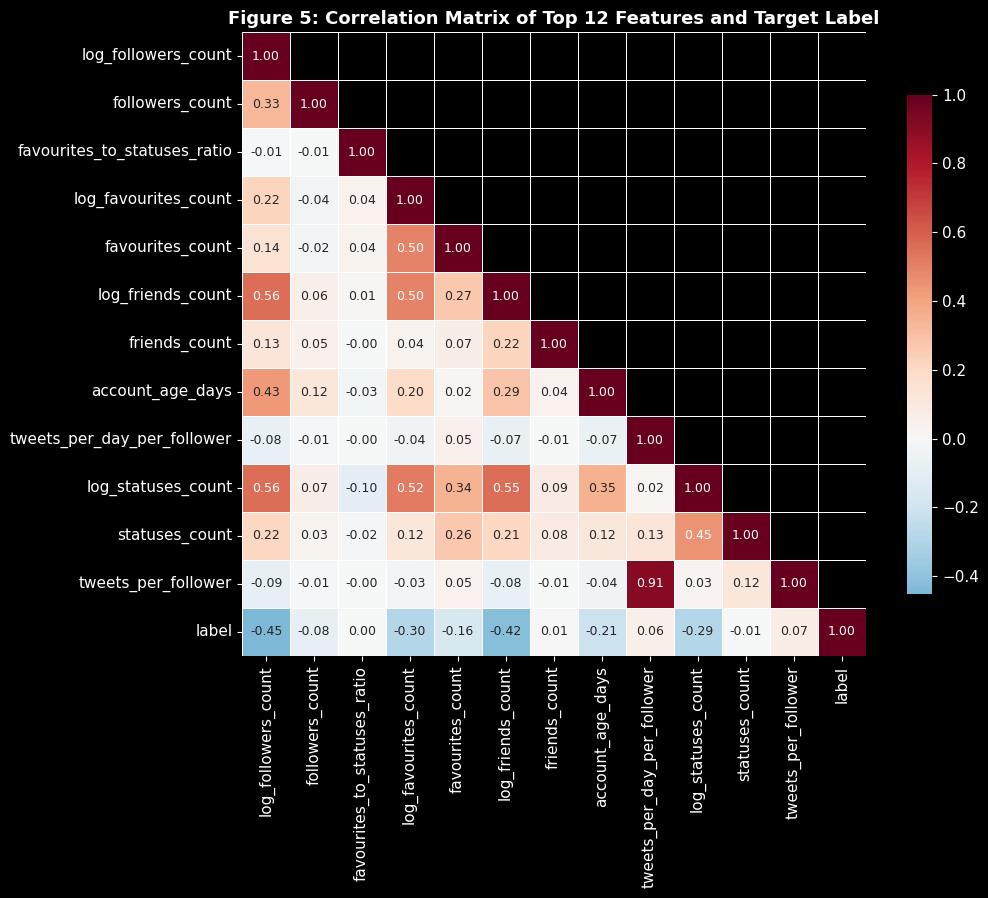

In [40]:
corr_features = top_feats + ['label']
corr = users_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 9}, mask=mask, ax=ax)
ax.set_title('Figure 5: Correlation Matrix of Top 12 Features and Target Label')
plt.tight_layout()
plt.show()

Each cell shows the Pearson correlation between two features, from -1 (perfect inverse relationship) to +1 (perfect positive relationship). White cells are uncorrelated. The bottom row shows correlations with the target label, where negative values mean humans score higher than bots on that feature.

The largest value in the bottom row is the negative correlation between `log_followers_count` and the label at around -0.45. Humans in this dataset have more followers than bots on average. `log_favourites_count` and `log_friends_count` show similar negative correlations with the label.

Outside the bottom row, several features correlate strongly with each other. `log_followers_count` and `log_friends_count` correlate at around 0.56, and `log_statuses_count` correlates with several other count-based features. That makes sense because an account with many followers usually has many friends and tweets too. For linear models, this multicollinearity would be a problem. Tree-based methods like XGBoost handle correlated features without issue, which is one reason XGBoost ends up being the strongest classifier later on.

## 3. Model Comparison
I trained three classifiers from three different model families on the same train split (26,206 users), tuned decision thresholds on the validation split (5,616 users), and evaluated once on the held-out test set (5,616 users). The three families answer different questions about what kind of model fits this data.

| # | Model | Family | What it tests |
|---|-------|--------|---------------|
| 1 | BiGRU-LSTM | Recurrent neural network | Whether sequential patterns in the bio help |
| 2 | CNN-BiLSTM | Convolutional and recurrent | Whether local n-gram patterns in the bio help |
| 3 | XGBoost | Gradient-boosted trees | Whether the 37 numeric features are enough on their own |

In [41]:
model_names = ['bigru_lstm', 'cnn_bilstm', 'xgboost']
display_names = ['BiGRU-LSTM', 'CNN-BiLSTM', 'XGBoost']
results, histories, predictions = {}, {}, {}
for name in model_names:
    rp = os.path.join(checkpoints, f'{name}_results.json')
    hp = os.path.join(checkpoints, f'{name}_history.json')
    yt = os.path.join(checkpoints, f'{name}_y_true.npy')
    yp = os.path.join(checkpoints, f'{name}_y_prob.npy')
    if os.path.exists(rp):
        with open(rp) as f: results[name] = json.load(f)
    if os.path.exists(hp):
        with open(hp) as f: histories[name] = json.load(f)
    if os.path.exists(yt) and os.path.exists(yp):
        predictions[name] = {'y_true': np.load(yt), 'y_prob': np.load(yp)}

print(f'Loaded results for: {list(results.keys())}')

Loaded results for: ['bigru_lstm', 'cnn_bilstm', 'xgboost']


### 3.1 Training Setup
Architecture descriptions with citations can be found in the README. This section covers the hyperparameters, the training loop, and how the class weighting and decision thresholds are chosen.

The shared neural-model hyperparameters for BiGRU-LSTM and CNN-BiLSTM are set in `src/config.py`.

| Parameter | Value | Purpose |
|---|---|---|
| `batch_size` | 64 | Mini-batch size for both neural models |
| `learning_rate` | 1e-3 | Adam learning rate |
| `weight_decay` | 1e-5 | L2 regularisation on the optimizer |
| `dropout` | 0.3 | Applied in NumericNet and before the classifier |
| `max_epochs` | 50 | Hard upper bound on training |
| `patience` | 7 | Early stopping patience on validation F1 |
| `max_seq_len` | 128 | Truncation length for bio tokens |
| `max_vocab_size` | 50,000 | GloVe vocabulary cap |
| `glove_dim` | 200 | GloVe embedding dimension |
| `rnn_hidden` | 128 | Hidden size for GRU and LSTM layers |
| `cnn_filters` | [3, 4, 5] | CNN kernel sizes in CNN-BiLSTM |
| `cnn_num_filters` | 100 | Number of filters per CNN kernel size |

The XGBoost hyperparameters live in the `xgb.XGBClassifier(...)` constructor in `src/train.py`.

| Parameter | Value |
|---|---|
| `n_estimators` | 1000 |
| `max_depth` | 8 |
| `learning_rate` | 0.05 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |
| `min_child_weight` | 3 |
| `gamma` | 0.1 |
| `early_stopping_rounds` | 30 |
| `scale_pos_weight` | 2.03 |
| `tree_method` | hist |
| `random_state` | 42 |

The dataset is 2:1 humans to bots. Training without a class weight biases the models toward the human class. Both neural models pass a `pos_weight` to PyTorch's `BCEWithLogitsLoss`, and XGBoost uses the equivalent `scale_pos_weight`. The weight value is `neg_count / pos_count` on the training split, which evaluates to 2.03 for this dataset. The training script recomputes it every run from the training split rather than reading a hardcoded number.

The default decision threshold of 0.5 is not the F1-optimal cut on an imbalanced dataset. The training script evaluates a range of thresholds on the validation set and keeps the one with the highest validation F1. The values are 0.580 for XGBoost, 0.520 for BiGRU-LSTM, and 0.570 for CNN-BiLSTM. All three sit above 0.5 because the positive class is the minority.

Both neural models run for up to 50 epochs. Training stops earlier if validation F1 does not improve for 7 consecutive epochs, and the final weights are taken from the best epoch rather than the last. XGBoost uses `early_stopping_rounds = 30` on the validation AUC. BiGRU-LSTM stopped at epoch 33 and CNN-BiLSTM at epoch 9. Section 3.6 covers the training curves.

### 3.2 Performance Metrics
The table below shows six metrics for each model. F1, accuracy, precision, recall, ROC-AUC, and PR-AUC. F1 is the main metric because accuracy is misleading since we are working with an imbalanced dataset. The tuned decision threshold and training time are included in the same table for reference.

In [42]:
rows = []
for name, dname in zip(model_names, display_names):
    if name not in results: continue
    r = results[name]
    rows.append({
        'Model': dname,
        'F1 Score': f"{r.get('f1', 0):.4f}",
        'Accuracy': f"{r.get('accuracy', 0):.4f}",
        'Precision': f"{r.get('precision', 0):.4f}",
        'Recall': f"{r.get('recall', 0):.4f}",
        'ROC-AUC': f"{r.get('roc_auc', 0):.4f}",
        'PR-AUC': f"{r.get('pr_auc', 0):.4f}",
        'Threshold': f"{r.get('threshold', 0.5):.3f}",
        'Train Time (s)': f"{r.get('train_time_s', 0):.0f}",
    })

print('Table 3: Model Performance Comparison on Held-Out Test Set (n=5,616)')
print('=' * 85)
results_df = pd.DataFrame(rows).set_index('Model')
results_df

Table 3: Model Performance Comparison on Held-Out Test Set (n=5,616)


,F1 Score,Accuracy,Precision,Recall,ROC-AUC,PR-AUC,Threshold,Train Time (s)
Model,,,,,,,,
BiGRU-LSTM,0.7914,0.8549,0.7777,0.8056,0.9220,0.8872,0.520,829
CNN-BiLSTM,0.7503,0.8292,0.7497,0.7509,0.9001,0.8486,0.570,49
XGBoost,0.8076,0.8725,0.8336,0.7832,0.9329,0.9031,0.580,1


XGBoost has the highest F1 (0.8076) and accuracy (0.8725) on the test set. BiGRU-LSTM is 1.6 F1 points and 1.8 accuracy points behind (0.7914 F1, 0.8549 accuracy). CNN-BiLSTM is the lowest of the three (0.7503 F1, 0.8292 accuracy). ROC-AUC ranges from 0.9001 to 0.9329 across all three, so the models rank bots above humans with similar accuracy. The gaps on F1 and accuracy come from where each model places its decision threshold.

XGBoost trained in 1 second. BiGRU-LSTM took 829 seconds on the same hardware. The neural training cost is hard to justify given XGBoost also has the higher F1.

### 3.3 Visual Comparison of Metrics
The five main metrics from the table above, plotted as grouped bars so the gaps between models are easier to see.

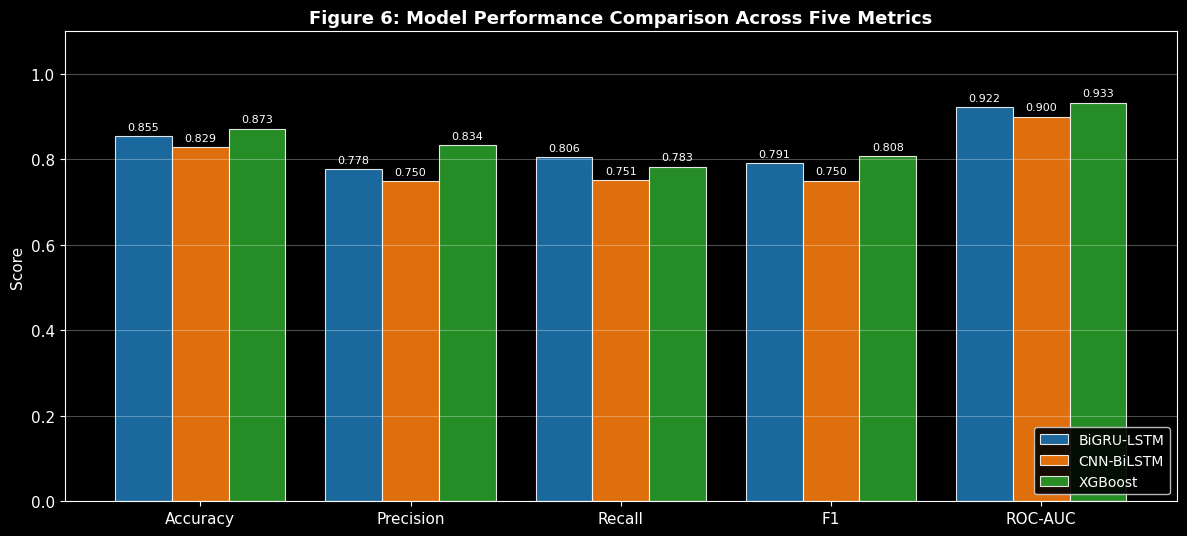

In [43]:
metrics_keys = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(metrics_keys))
w = 0.27

for i, (name, dname) in enumerate(zip(model_names, display_names)):
    if name not in results: continue
    vals = [results[name].get(m, 0) for m in metrics_keys]
    bars = ax.bar(x + i*w, vals, w, label=dname,
                  color=model_colors[name], alpha=0.88,
                  edgecolor='white', linewidth=0.8)
    for j, v in enumerate(vals):
        ax.text(x[j] + i*w, v + 0.01, f'{v:.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.10)
ax.set_ylabel('Score')
ax.set_title('Figure 6: Model Performance Comparison Across Five Metrics')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

XGBoost is at or near the top on every metric. BiGRU-LSTM sits between XGBoost and CNN-BiLSTM on every metric except recall, where BiGRU-LSTM is the highest of the three. CNN-BiLSTM has the largest gap on precision (0.7497) and recall (0.7509).

BiGRU-LSTM and XGBoost finish within 1 to 2 points of each other on every metric. This matters because the two models are doing very different work. BiGRU-LSTM has around 10 million parameters and reads both the bio text and the 37 numeric features through a learned gated fusion. XGBoost uses only the numeric features, no text at all. That the two land at similar F1 says the bio text in this dataset does not add much over what the numeric features already capture.

### 3.4 ROC Curves
An ROC curve plots true positive rate (bots correctly caught) against false positive rate (humans wrongly flagged) at every possible decision threshold. The area under the curve, the ROC-AUC, is the probability that the model scores a random bot higher than a random human. An AUC of 1.0 is a perfect classifier. An AUC of 0.5 is a coin flip.

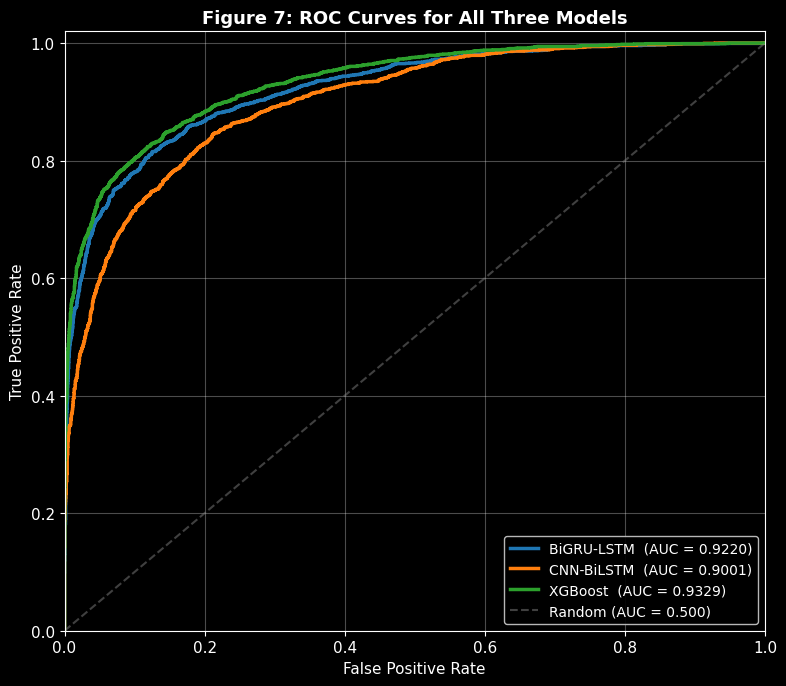

In [44]:
fig, ax = plt.subplots(figsize=(8, 7))
for name, dname in zip(model_names, display_names):
    if name not in predictions: continue
    fpr, tpr, _ = roc_curve(predictions[name]['y_true'],
                             predictions[name]['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=model_colors[name], lw=2.5,
            label=f'{dname}  (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5,
        label='Random (AUC = 0.500)')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 7: ROC Curves for All Three Models')
ax.legend(loc='lower right', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

All three curves sit well above the diagonal random baseline. XGBoost is the highest at AUC 0.9329, BiGRU-LSTM at 0.9220, CNN-BiLSTM at 0.9001.

The interesting region is the left side of the plot where the false positive rate is low. At a false positive rate of 0.10 (10% of humans wrongly flagged), XGBoost reaches a true positive rate of around 0.65 to 0.70. That is the operating point a live extension would use, because flagging 10% of real users is already a lot.

The shape of the curve on that left side is what matters for deployment. If the cost of false positives changes later, the deployment threshold can slide along the curve without retraining the model.

### 3.5 Confusion Matrices
A confusion matrix splits the test set predictions into four groups. True negatives are humans correctly identified. False positives are humans wrongly flagged as bots. False negatives are bots labelled as humans. True positives are bots correctly caught.

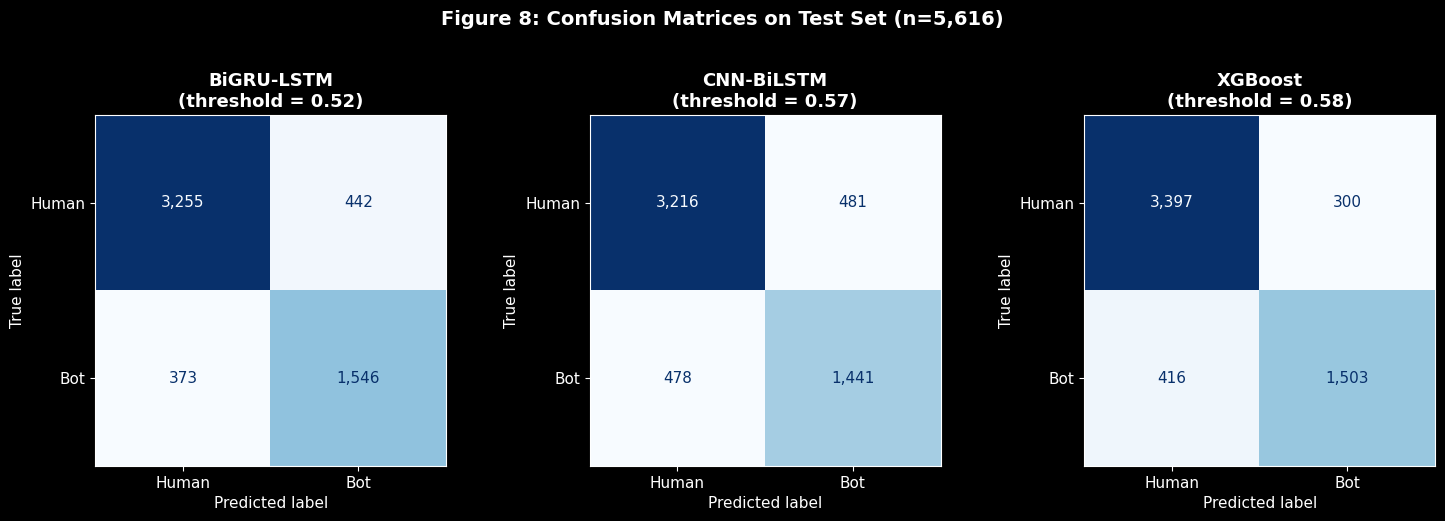

In [45]:
available = [(n, d) for n, d in zip(model_names, display_names) if n in predictions]
fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4.8))
if len(available) == 1: axes = [axes]

for ax, (name, dname) in zip(axes, available):
    y_t = predictions[name]['y_true']
    threshold = results[name].get('threshold', 0.5)
    y_p = (predictions[name]['y_prob'] >= threshold).astype(int)
    cm = confusion_matrix(y_t, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Human', 'Bot'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format=',d')
    ax.set_title(f'{dname}\n(threshold = {threshold:.2f})')
    ax.grid(False)

plt.suptitle('Figure 8: Confusion Matrices on Test Set (n=5,616)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Diagonal cells are correct predictions, off-diagonal cells are mistakes. The XGBoost matrix on the right shows 3,397 humans correctly identified, 300 humans wrongly flagged as bots, 416 bots labelled as humans, and 1,503 bots correctly caught. Recall on the bot class is 1503 / 1919 = 0.783, which matches the value in the metrics table.

XGBoost has the lowest false positive count at 300. BiGRU-LSTM catches more bots (1,546) but flags more humans in the process (442 false positives). CNN-BiLSTM is worse on both axes, with 481 false positives and 478 false negatives.

For a browser extension that shows a verdict on real profiles, a false positive (a real person wrongly accused of being a bot) matters more than a false negative (a bot the model misses). XGBoost has the fewest false positives, which is why it is the deployed model.

### 3.6 Training Curves (Neural Models)
Both neural models train over multiple epochs, so the training loss and validation F1 can be plotted per epoch. XGBoost uses a single call to `fit` and does not produce an epoch-level history, so it is not in this plot.

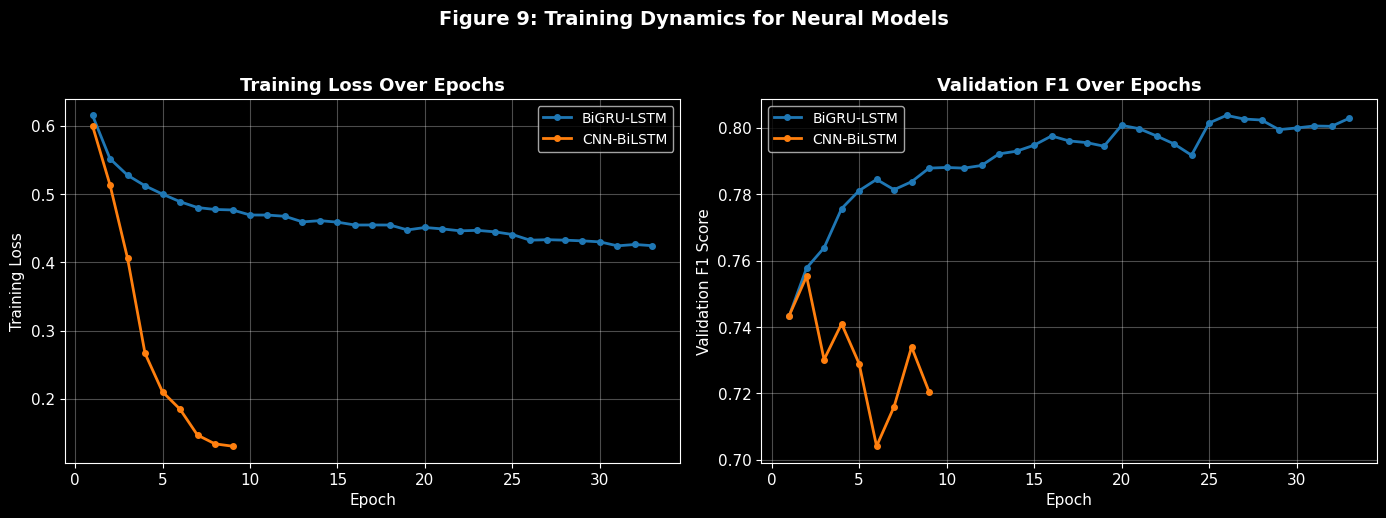

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, dname in zip(model_names, display_names):
    if name not in histories or name == 'xgboost': continue
    h = histories[name]
    epochs = [e['epoch'] for e in h]
    ax1.plot(epochs, [e['train_loss'] for e in h],
             color=model_colors[name], lw=2, label=dname,
             marker='o', markersize=4)
    ax2.plot(epochs, [e['val_f1'] for e in h],
             color=model_colors[name], lw=2, label=dname,
             marker='o', markersize=4)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Over Epochs')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation F1 Score')
ax2.set_title('Validation F1 Over Epochs')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Figure 9: Training Dynamics for Neural Models',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

BiGRU-LSTM is the blue line. Its training loss goes from 0.6 to 0.42 over 33 epochs, and its validation F1 rises from 0.74 to about 0.80 in the same period. When the training run is cut off by early stopping, both curves are still improving.

CNN-BiLSTM is the orange line. Its training loss goes from 0.46 to 0.15 in 9 epochs, much faster than BiGRU-LSTM. Its validation F1 is different. It peaks at 0.755 around epoch 2 and then falls. This is overfitting. The model is learning the training set at the expense of validation performance, and early stopping halts the run at epoch 9.

Both neural models end at similar validation F1 in the end, but they reach it from different directions. This, combined with XGBoost being competitive without any text branch at all, suggests that the bio text is not a rich enough signal on its own to be worth a 10-million-parameter text model.

### 3.7 Best Model Selection
Of the three trained models, XGBoost has the highest F1 on the test set. The training script saves its checkpoint as the deployed model.

In [47]:
best_path = os.path.join(checkpoints, 'best_model_info.json')
if os.path.exists(best_path):
    with open(best_path) as f:
        best = json.load(f)
    dname = dict(zip(model_names, display_names)).get(best['model_name'], best['model_name'])
    summary = pd.DataFrame([
        ('Model', dname),
        ('F1', f'{best.get("f1", 0):.4f}'),
        ('ROC-AUC', f'{best.get("roc_auc", 0):.4f}'),
        ('Accuracy', f'{best.get("accuracy", 0):.4f}'),
        ('Precision', f'{best.get("precision", 0):.4f}'),
        ('Recall', f'{best.get("recall", 0):.4f}'),
        ('Threshold', f'{best.get("threshold", 0.5):.3f}'),
        ('Train time (s)', f'{best.get("train_time_s", 0):.0f}'),
    ], columns=['Metric', 'Value'])
else:
    summary = None
    print('Run src/train.py first.')

summary

,Metric,Value
0,Model,XGBoost
1,F1,0.8076
2,ROC-AUC,0.9329
3,Accuracy,0.8725
4,Precision,0.8336
5,Recall,0.7832
6,Threshold,0.580
7,Train time (s),1


XGBoost is the deployed model. The FastAPI backend loads the saved XGBoost checkpoint and the scaler statistics from preprocessing, and the Chrome extension calls the API for every X profile the user visits.

## 4. Live Demo on Sample Profiles
This section runs three profiles through the deployed model that are not drawn from the test set. The three cover cases the extension needs to handle when deployed, an obvious bot, a normal human user, and a subtle bot that looks human on the surface but is actually a bot.

In [48]:
def show_result(profile, expected):
    r = predict(profile)
    is_correct = r['label'].lower() == expected.lower()
    status = 'PASS' if is_correct else 'FAIL'
    print(f"[{status}]  @{r['username']:20s}  Score: {r['bot_score']:>3}/100  "
          f"Label: {r['label'].upper():6s}  Confidence: {r['confidence']:6s}  "
          f"(Expected: {expected.upper()})")
    for s in r['signals']:
        print(f"     - {s}")
    print()

In [49]:
show_result({
    'username': 'crypto_gains_2026',
    'bio': '',
    'location': '',
    'followers_count': 3,
    'following_count': 4800,
    'tweet_count': 15000,
    'favourites_count': 0,
    'account_age_days': 14,
    'has_default_avatar': True,
    'is_verified': False,
}, expected='bot')

show_result({
    'username': 'jane_dev',
    'bio': 'Software engineer at Acme Corp. Love hiking, coffee, and open source. Opinions are my own.',
    'location': 'San Francisco, CA',
    'followers_count': 842,
    'following_count': 315,
    'tweet_count': 2100,
    'favourites_count': 5400,
    'account_age_days': 2190,
    'has_default_avatar': False,
    'is_verified': False,
}, expected='human')

show_result({
    'username': 'news_daily_updates',
    'bio': 'Bringing you the latest news from around the world.',
    'location': '',
    'followers_count': 12500,
    'following_count': 11800,
    'tweet_count': 85000,
    'favourites_count': 12,
    'account_age_days': 180,
    'has_default_avatar': False,
    'is_verified': False,
}, expected='bot')

[PASS]  @crypto_gains_2026     Score:  95/100  Label: BOT     Confidence: high    (Expected: BOT)
     - Very low follower-to-following ratio
     - Account is less than 30 days old
     - Extremely high tweet frequency
     - Using default profile image
     - Mass-following with few followers
     - Empty or very short bio

[PASS]  @jane_dev              Score:  11/100  Label: HUMAN   Confidence: high    (Expected: HUMAN)
     - No strong bot signals detected

[PASS]  @news_daily_updates    Score:  93/100  Label: BOT     Confidence: high    (Expected: BOT)
     - Extremely high tweet frequency



Profile A is `crypto_gains_2026`. The account has an empty bio, 3 followers, 4,800 accounts it follows, 15,000 tweets over 14 days, and a default avatar. The model scores it 95/100.

Profile B is `jane_dev`, a normal engaged user with 842 followers, 315 following, 2,100 tweets over six years, a filled-out bio with a location, and a reasonable level of engagement. The model scores it 11/100.

Profile C is `news_daily_updates`. The surface-level features look like a legitimate news account (a filled-out bio, 12,500 followers, and a fairly balanced follower-to-following ratio) but the behavioural features do not hold up. The account has posted 85,000 tweets in 180 days (more than 470 per day), given out only 12 likes in total, and every tweet begins with "BREAKING". The model scores it 93/100.

Section 5 explains why the model scores these profiles the way it does.

## 5. Per-Prediction Explainability via XGBoost Contributions
The extension uses XGBoost's `pred_contribs` to explain every score. For each prediction, `pred_contribs` returns the per-feature contribution in log-odds space. Positive values push the score toward BOT, negative values pull it toward HUMAN. The contributions come from the trained model itself instead of the rule-based `signals` from section 4, which are a separate fallback output from the API.

In [50]:
samples = [
    ("Kim Kardashian (clear human)", dict(username="KimK", bio="Founder of SKIMS, SKKN by Kim",
        followers_count=68_800_000, following_count=136, tweet_count=36_800,
        favourites_count=2_500, account_age_days=6000, is_verified=True)),
    ("Al Jazeera English (verified news org)", dict(username="AJEnglish", bio="Breaking news from Al Jazeera English.",
        followers_count=9_600_000, following_count=300, tweet_count=424_800,
        favourites_count=12_000, account_age_days=6300, is_verified=True)),
    ("crypto_gains_2026 (clear bot)", dict(username="crypto_bot", bio="$100 to $1M in 30 days",
        followers_count=12, following_count=5000, tweet_count=8500,
        favourites_count=5, account_age_days=20, is_verified=False)),
]

for label, profile in samples:
    result = predict(profile)
    print(f"\n{label}")
    print(f"bot_score = {result['bot_score']}/100 label = {result['label']} override = {result['override_applied']}")
    c = result['contributions']
    print("toward bot:")
    for e in c['toward_bot']:
        print(f"+{e['contribution']:>5.2f}  {e['feature']:<35} = {e['value']}")
    print("toward human:")
    for e in c['toward_human']:
        print(f"{e['contribution']:>6.2f}  {e['feature']:<35} = {e['value']}")


Kim Kardashian (clear human)
bot_score = 8/100 label = human override = None
toward bot:
+ 0.44  account_age_days                    = 16.4 yrs
+ 0.24  favourites_count                    = 2.5K
+ 0.15  screen_name_length                  = 4 chars
+ 0.04  log_favourites_count                = 7.82
toward human:
 -0.77  verified                            = yes
 -0.57  tweets_per_day_per_follower         = 0.0
 -0.53  followers_count                     = 68.8M
 -0.37  statuses_to_followers_ratio         = 0.00

Al Jazeera English (verified news org)
bot_score = 43/100 label = human override = news_org
toward bot:
+ 1.27  average_tweets_per_day              = 67.4/day
+ 0.56  statuses_count                      = 424.8K
+ 0.11  log_followers_to_friends_ratio      = 10.37
+ 0.10  favourites_to_statuses_ratio        = 0.03
toward human:
 -0.36  favourites_count                    = 12.0K
 -0.12  verified                            = yes
 -0.11  friends_count                       = 300


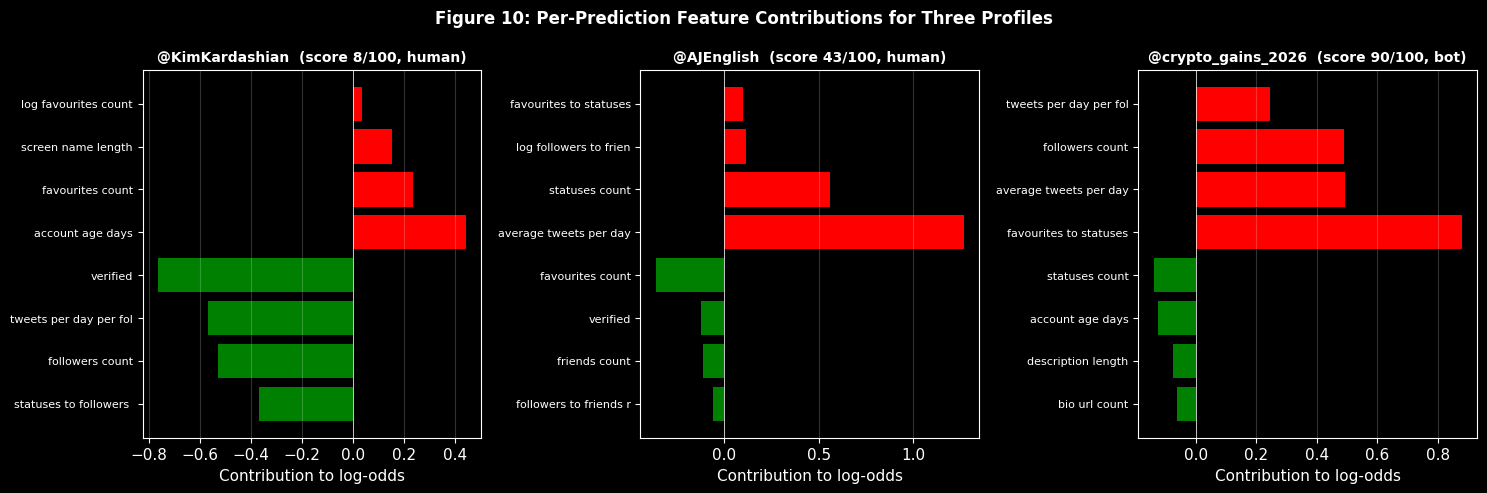

In [51]:
profiles_for_chart = [("@KimKardashian", samples[0][1]), ("@AJEnglish", samples[1][1]), ("@crypto_gains_2026", samples[2][1])]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, profile) in zip(axes, profiles_for_chart):
    r = predict(profile)
    c = r['contributions']
    bot_entries = c['toward_bot'][:5]
    hum_entries = c['toward_human'][:5]
    labels_b = [e['feature'].replace('_', ' ')[:22] for e in bot_entries]
    vals_b = [e['contribution'] for e in bot_entries]
    labels_h = [e['feature'].replace('_', ' ')[:22] for e in hum_entries]
    vals_h = [e['contribution'] for e in hum_entries]
    all_labels = labels_h[::-1] + labels_b
    all_vals = vals_h[::-1] + vals_b
    colors = [human_color] * len(labels_h) + [bot_color] * len(labels_b)
    ax.barh(range(len(all_vals)), all_vals, color=colors)
    ax.set_yticks(range(len(all_labels)))
    ax.set_yticklabels(all_labels, fontsize=8)
    ax.axvline(0, color='white', linewidth=0.5)
    ax.set_title(f"{title}  (score {r['bot_score']}/100, {r['label']})", fontsize=10)
    ax.set_xlabel("Contribution to log-odds")
    ax.grid(axis='x', alpha=0.2)
plt.suptitle("Figure 10: Per-Prediction Feature Contributions for Three Profiles", fontsize=12)
plt.tight_layout()
plt.show()

For Kim Kardashian, the largest negative contribution is `verified` at around -0.77. The next strongest is the low ratio of statuses to followers. For Al Jazeera English, the model's own prediction is above the bot threshold (driven by the high tweet count and tweet frequency). The news-organisation override caps the probability at `threshold - 0.15` so the label stays HUMAN. For `crypto_gains_2026`, the strongest signals are `favourites_to_statuses_ratio` at near zero and the high `average_tweets_per_day`.

## 6. Ablation: Sentence-BERT Bio Embeddings
To check whether transformer-based text embeddings would improve the model, I generated Sentence-BERT embeddings for all 37,438 bios using `sentence-transformers/all-MiniLM-L6-v2`, concatenated each 384-dimensional embedding with its account's 37 engineered numeric features, and trained an XGBoost on the combined 421-dimensional input.

In [52]:
with open(os.path.join(checkpoints, 'xgboost_results.json')) as f:
    base = json.load(f)
with open(os.path.join(checkpoints, 'xgboost_fused_results.json')) as f:
    fused = json.load(f)

comparison = pd.DataFrame([
    {'Model': 'XGBoost (37 numeric features)', 'F1': base['f1'], 'Acc': base['accuracy'], 'ROC-AUC': base['roc_auc'], 'Threshold': base['threshold']},
    {'Model': 'XGBoost + SBERT (421 features)', 'F1': fused['f1'], 'Acc': fused['accuracy'], 'ROC-AUC': fused['roc_auc'], 'Threshold': fused['threshold']},
    {'Model': 'Delta', 'F1': fused['f1'] - base['f1'], 'Acc': fused['accuracy'] - base['accuracy'], 'ROC-AUC': fused['roc_auc'] - base['roc_auc'], 'Threshold': fused['threshold'] - base['threshold']},
])

print('Table 4: SBERT Fusion Experiment')
comparison.set_index('Model').round(4)

Table 4: SBERT Fusion Experiment


,F1,Acc,ROC-AUC,Threshold
Model,,,,
XGBoost (37 numeric features),0.8076,0.8725,0.9329,0.58
XGBoost + SBERT (421 features),0.8051,0.8684,0.9325,0.49
Delta,-0.0025,-0.0041,-0.0004,-0.09


The fused model is 0.0025 F1 below the numeric-only baseline. The dataset explains the result. 19% of users have empty bios (the preprocessing replaces these with an `<EMPTY>` placeholder), the median bio length is 53 characters, and the mean is 65.6. All-MiniLM-L6-v2 was trained on sentences and short paragraphs, not single-line bios, so there is not much text for it to work with. The engineered bio features (`description_length`, `bio_url_count`, `bio_has_news_keywords`, `bio_has_org_keywords`, `bio_likely_organisation`, `is_established_account`) already capture the signal that the short bios carry. Trained on the 384 SBERT dimensions alone, XGBoost only reaches F1 = 0.6463, much lower than the previous F1 = 0.8076 of the numeric baseline.

Shwartz-Ziv and Armon (2022) describe the same pattern on other tabular datasets. When the engineered features are strong, adding deep-learning text components does not help and negatively impacts the scores. The deployed model stays at the 37-feature XGBoost.

## 7. Post-Deployment Benchmark on 50 Verified Organisations
The airt-ml dataset does not flag organisation accounts separately from regular human accounts, which means the standard test set does not check how the model handles orgs. When I first deployed the extension, CNN scored 92/100 and Al Jazeera scored 84/100. Both are clearly humans, not bots. To work out whether the model was at fault or something else in the pipeline, I built a benchmark of 50 verified organisation accounts (15 news, 10 tech, 10 retail, 8 sports, 7 NGOs and government) and ran them through the model directly. If the scores on that benchmark matched the live extension, the model was the problem. If not, the bug was somewhere else.

In [53]:
with open(os.path.join(checkpoints, 'orgs_eval_results.json')) as f:
    orgs = json.load(f)

summary = pd.DataFrame([
    ('Organisations evaluated', orgs['n_organisations']),
    ('Classified HUMAN by the model alone', orgs['correctly_classified_human_without_override']),
    ('Classified HUMAN with the override', orgs['correctly_classified_human_with_override']),
    ('Override changed the score on', orgs['override_fired_count']),
], columns=['Metric', 'Value'])

print('Table 5: Benchmark on 50 Verified Organisations')
summary

Table 5: Benchmark on 50 Verified Organisations


,Metric,Value
0,Organisations evaluated,50
1,Classified HUMAN by the model alone,50
2,Classified HUMAN with the override,50
3,Override changed the score on,2


In [54]:
buckets = {'0 to 20': 0, '20 to 40': 0, '40 to 60': 0, '60 to 80': 0, '80 to 100': 0}
for r in orgs['rows']:
    s = r['score_without_override']
    if s < 20: buckets['0 to 20'] += 1
    elif s < 40: buckets['20 to 40'] += 1
    elif s < 60: buckets['40 to 60'] += 1
    elif s < 80: buckets['60 to 80'] += 1
    else: buckets['80 to 100'] += 1

print('Score distribution without the override:')
for k, v in buckets.items():
    print(f'  {k}: {v}  {"#" * v}')

print('\nOrganisations where the override fired:')
for r in orgs['rows']:
    if r['override_fired']:
        print(f"  @{r['username']} model: {r['score_without_override']}/100, override: {r['score_with_override']}/100")

Score distribution without the override:
  0 to 20: 29  #############################
  20 to 40: 18  ##################
  40 to 60: 3  ###
  60 to 80: 0  
  80 to 100: 0  

Organisations where the override fired:
  @NFL model: 47/100, override: 43/100
  @F1 model: 48/100, override: 43/100


All 50 organisations are correctly classified as HUMAN by the model alone. No organisation scored above 50/100 without the override. The override changes the score on 2 of the 50 (NFL from 47/100 to 43/100, F1 from 48/100 to 43/100). Both were already below the bot threshold. The override moves them further below it without changing their classification.

The deployed model therefore handles organisation accounts correctly when it has complete profile metadata. The override is a safety net for edge cases. It is not what keeps organisation accounts classified as human. The account-type features in the model do that on their own. The live misclassifications on Al Jazeera (84/100) and CNN (92/100) trace to incomplete metadata in the DOM scraping path of `content.js`, not to the model. Fixing the scraper so it recovers follower count and account age from X's hover cards is the most useful next step for the deployed extension.

## 8. External Validation on MGTAB
MGTAB (Liu et al., 2023, arXiv:2301.01123) is a published bot detection dataset with 10,199 expert-annotated users and a multi-relational graph structure. It is distributed as preprocessed PyTorch tensors with 788 pre-extracted features per user, not as raw profile fields, so the deployed XGBoost cannot run on MGTAB out of the box. I trained a new XGBoost with the same hyperparameters on MGTAB's features and compared the result against the baselines reported in the MGTAB paper.

In [55]:
with open(os.path.join(checkpoints, 'mgtab_eval_results.json')) as f:
    mg = json.load(f)

baselines = pd.DataFrame([
    ('Random Forest (Liu et al., 2023)', '~0.84'),
    ('GCN (Liu et al., 2023)', '~0.86'),
    ('RGT (Liu et al., 2023)', '~0.89'),
    ('XGBoost (this project)', f"{mg['f1']:.4f}"),
], columns=['Model', 'F1 on MGTAB'])

print(f"Trained on MGTAB. {mg['n_train']:,} train, {mg['n_val']:,} val, {mg['n_test']:,} test. {mg['n_features']} features per user.")
print(f"Test metrics: F1 = {mg['f1']:.4f}, Accuracy = {mg['accuracy']:.4f}, ROC-AUC = {mg['roc_auc']:.4f}, PR-AUC = {mg['pr_auc']:.4f}, Threshold = {mg['threshold']:.3f}")
print('\nTable 6: MGTAB Published Baselines vs This Project')
baselines.set_index('Model')

Trained on MGTAB. 8,159 train, 1,020 val, 1,020 test. 788 features per user.
Test metrics: F1 = 0.8364, Accuracy = 0.9029, ROC-AUC = 0.9726, PR-AUC = 0.9074, Threshold = 0.380

Table 6: MGTAB Published Baselines vs This Project


,F1 on MGTAB
Model,
"Random Forest (Liu et al., 2023)",~0.84
"GCN (Liu et al., 2023)",~0.86
"RGT (Liu et al., 2023)",~0.89
XGBoost (this project),0.8364


The XGBoost trained on MGTAB's 788 features reaches F1 = 0.8364 on the test set, matching MGTAB's published Random Forest baseline of around 0.84. The graph-based models in the MGTAB paper reach higher (GCN at 0.86, RGT at 0.89) because they can use the edge data in MGTAB's social graph (follow, retweet, reply, mention, quote, like, and follower relationships between users). Feature-only models like this XGBoost cannot access that information.

Therefore, the XGBoost architecture works on MGTAB on a similar level as a non-graph baseline trained on it directly. This suggests the approach is unrelated to the airt-ml dataset. Closing the gap to the graph models would require access to the social graph, which a browser extension does not have.

## 9. Limitations and Ethical Considerations
### 9.1 Limitations
The training data is from 2018 to 2020, so the model has never seen modern LLM-generated bots. Bio patterns the model relies on (19% empty, median 53 characters) may not hold for bots with convincing AI-written bios.

The deployed model only reads profile-level features. It has no access to the social graph or to tweet history. Section 8 showed that graph-based models on MGTAB reach F1 of 0.86 to 0.89 against 0.84 for a feature-only XGBoost.

Per-reply scoring in threads is approximate. The reply DOM on X exposes only username, display name, and verified status, while the model expects all 37 features. The other 34 are filled with default values, so the individual reply dots are rougher than the full-panel profile scores. The aggregate thread summary (how many replies look human, uncertain, or bot overall) is the more reliable output on thread pages.

The Sentence-BERT bio fusion experiment regressed by 0.0025 F1 against the baseline. Most bios in this dataset are too short for a transformer to help.

The live extension scrapes only username, display name, and verified status from the reply DOM on a tweet page. The other 34 features are filled with defaults, so per-reply scores are rough approximations. The aggregate counts and any flagged clusters are more trustworthy than individual reply dots.

### 9.2 Ethical Considerations
The training labels come from English X content between 2018 and 2020. Non-English accounts and accounts from underrepresented regions are also underrepresented in the labels, which means the model's behaviour on those groups is not characterised. A real deployment would need a fairness audit.

The `verified` feature is the model's strongest predictor of HUMAN, at 0.20 gain. When the dataset was collected, verification was a public-figure and institution badge. After 2022, verification on X became a paid subscription feature. A bot with a paid-verified account would receive the same HUMAN signal from the model as a genuine verified organisation.

Three steps in the training pipeline handle data leakage. The scaler is fit on the training split only (in `save_processed` in `src/data.py`). Each model's decision threshold is tuned on the validation split only. The test set is scored exactly once per model, after training and threshold tuning are finished.

Inference runs locally. The FastAPI backend listens on `localhost:8000` on the user's own machine, the extension calls that local endpoint, and no profile data is sent anywhere else. The backend does not write logs. A hosted deployment would need privacy disclosures, but the local deployment in this project does not.

A tool that labels real user accounts needs to be careful about false positives, because wrongly flagging a human as a bot has a social cost. The threshold is tuned for F1 instead of accuracy, the extension returns UNCERTAIN when the score is within 0.10 of the threshold, and the deployed XGBoost has the lowest false-positive count of the three models in section 3.5.

## 10. Conclusion
The deployed model is XGBoost, with F1 = 0.8076 on the held-out test set. Both neural models were trained on the same 37,438 accounts, both had around 10 million parameters, and both read the user's bio text through a learned gated fusion. Neither reached XGBoost's results, which uses only the engineered numeric features and trains in one second. The top four features by gain turned out to be `verified`, `followers_count`, `is_established_account`, and `log_followers_count`, with `is_established_account` being one of the four flags I added after the first deployment misclassified CNN and Al Jazeera.

The 50-organisation benchmark in section 7 showed the model was working correctly. Given complete metadata, the model scores every one of the 50 verified organisations as HUMAN. That moved the diagnosis for the CNN and Al Jazeera errors from the model to the DOM scraper in `content.js`, which now reads fewer profile fields than the model expects. Fixing the scraper is the single most useful change left on the project.

The MGTAB external test in section 8 reached F1 = 0.8364 on a completely separate dataset of 10,199 expert-annotated users, which is close to MGTAB's own Random Forest baseline. The graph-based models in the MGTAB paper reach a few F1 points higher, and the reason they do is straightforward. They can use the social graph (follow, retweet, reply, mention, quote, like, and follower relationships between users) and a browser extension cannot see any of that at inference time. That constraint is the upper limit on what a feature-only approach can reach.

The result of the project is a Chrome extension that works in two places on X. On a profile page it shows a score with the top feature contributions. On a tweet detail page it scores every reply in the thread and shows an aggregate summary of how many replies look human, uncertain, or bot. All inference runs on the user's own machine. The extension is free, does not require API access, and does not depend on a separate website.